# EDA (Exploratory Data Analysis)

## Import dependencies

In [156]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

## Read the dataset

In [328]:
dataset_directory = "../data"
dataset_file = "raw.csv"
dataset_path = os.path.join(dataset_directory, dataset_file)

dataset = pd.read_csv(filepath_or_buffer=dataset_path)

## Here we go!

#### Check the shape, where the (rows, columns) size:

In [13]:
dataset.shape

(7818, 26)

#### Check the features (columns) name:

In [14]:
dataset.columns.values

array(['Category Name', 'Category URL', 'Service Name', 'Service URL',
       'Offer Name', 'Offer URL', 'Offer Stars', 'Offer Raters',
       'Offer Response Time', 'Offer Buyers', 'Pending', 'Price',
       'Duration', 'Reviews', 'Available Additions', 'Additions Price',
       'Owner Name', 'Owner URL', 'Owner Verified', 'Owner Level',
       'Owner Stars', 'Owner Raters', 'Owner Completion Rate',
       'Owner Services', 'Owner Customers', 'Owner Response Time'],
      dtype=object)

#### Display the abstracted information:

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category Name          7818 non-null   object 
 1   Category URL           7818 non-null   object 
 2   Service Name           7818 non-null   object 
 3   Service URL            7818 non-null   object 
 4   Offer Name             7818 non-null   object 
 5   Offer URL              7818 non-null   object 
 6   Offer Stars            7818 non-null   float64
 7   Offer Raters           7818 non-null   int64  
 8   Offer Response Time    7818 non-null   object 
 9   Offer Buyers           7818 non-null   int64  
 10  Pending                7818 non-null   int64  
 11  Price                  7818 non-null   object 
 12  Duration               7818 non-null   object 
 13  Reviews                7818 non-null   int64  
 14  Available Additions    7818 non-null   int64  
 15  Addi

#### Calculate the statistical data of the numerical values:

In [17]:
dataset.describe()

,Offer Stars,Offer Raters,Offer Buyers,Pending,Reviews,Available Additions,Additions Price,Owner Stars,Owner Raters,Owner Services,Owner Customers
count,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000
mean,3.534408,11.149271,15.952417,0.068560,6.737529,2.599002,83.218854,3.821438,37.689563,4.232029,46.795856
std,2.181576,26.254233,39.947638,0.320158,8.480813,1.800739,107.176584,1.980483,75.171396,3.444568,97.192959
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,10.000000,4.500000,1.000000,2.000000,2.000000
50%,5.000000,3.000000,4.000000,0.000000,3.000000,3.000000,45.000000,5.000000,11.000000,3.000000,14.000000
75%,5.000000,10.000000,13.000000,0.000000,10.000000,4.000000,115.000000,5.000000,41.000000,5.000000,50.000000
max,5.000000,566.000000,821.000000,7.000000,25.000000,5.000000,900.000000,5.000000,1704.000000,28.000000,2393.000000


#### Count the missing values:

In [41]:
dataset.isnull().sum()

Category Name            0
Category URL             0
Service Name             0
Service URL              0
Offer Name               0
Offer URL                0
Offer Stars              0
Offer Raters             0
Offer Response Time      0
Offer Buyers             0
Pending                  0
Price                    0
Duration                 0
Reviews                  0
Available Additions      0
Additions Price          0
Owner Name               0
Owner URL                0
Owner Verified           0
Owner Level              0
Owner Stars              0
Owner Raters             0
Owner Completion Rate    0
Owner Services           0
Owner Customers          0
Owner Response Time      0
dtype: int64

#### Count the duplicated values:

In [38]:
dataset.duplicated().sum()

np.int64(0)

#### Count the unique values:

In [44]:
dataset.nunique()

Category Name              11
Category URL               11
Service Name              274
Service URL               279
Offer Name               7707
Offer URL                7816
Offer Stars                10
Offer Raters              186
Offer Response Time       104
Offer Buyers              241
Pending                     6
Price                      10
Duration                   10
Reviews                    26
Available Additions         6
Additions Price           125
Owner Name               3774
Owner URL                5857
Owner Verified              2
Owner Level                 9
Owner Stars                 9
Owner Raters              301
Owner Completion Rate    1240
Owner Services             28
Owner Customers           353
Owner Response Time       102
dtype: int64

#### Display a few samples:

In [76]:
dataset.sample(frac=1).drop_duplicates(subset="Category Name")

,Category Name,Category URL,Service Name,Service URL,Offer Name,Offer URL,Offer Stars,Offer Raters,Offer Response Time,Offer Buyers,...,Owner Name,Owner URL,Owner Verified,Owner Level,Owner Stars,Owner Raters,Owner Completion Rate,Owner Services,Owner Customers,Owner Response Time
7200,برمجة وتطوير,https://khamsat.com/programming,إدارة البريد الإلكتروني,https://khamsat.com/programming/email-management,عمل سيرفر خاص لاستضافة ايميلات شركتك youremail...,https://khamsat.com/programming/email-manageme...,5.0,1,4 ساعات,3,...,.Hani G,https://khamsat.com/user/hani-ghiath,True,بائع مميز,5.0,64,93.4%,9,66,ساعة
2810,تعليم عن بعد,https://khamsat.com/training,تعلم القرآن الكريم,https://khamsat.com/training/quran,درس في تجويد أو تحفيظ القرآن الكريم,https://khamsat.com/training/quran/1015137-%D8...,0.0,0,يوم,0,...,رجاء ح.,https://khamsat.com/user/ragaahassan,False,بائع جديد,0.0,0,0.0%,4,0,يوم
2373,هندسة وعمارة,https://khamsat.com/engineering,أنظمة المياه والصرف,https://khamsat.com/engineering/plumbing-drain...,تصميم الصرف الصحي و تغذية المياة للفيلا و المب...,https://khamsat.com/engineering/plumbing-drain...,4.5,8,3 ساعات,17,...,.Rana M,https://khamsat.com/user/rana_magdy_altawab,True,بائع مميز,4.5,28,97.11%,5,41,3 ساعات
715,تصميم,https://khamsat.com/designing,تصميم أيقونات,https://khamsat.com/designing/icon-design,خدمة تصميم أيقونات مخصصة واحترافية تلبي احتياجاتك,https://khamsat.com/designing/icon-design/2934...,0.0,0,لم يحسب,0,...,.Oussama S,https://khamsat.com/user/oussdrawing,False,بائع جديد,0.0,0,لم يحسب بعد,1,0,لم يحسب
3349,كتابة وترجمة,https://khamsat.com/writing,محتوى رياضي,https://khamsat.com/writing/sports-content,مقالات كروية ورياضية احترافية,https://khamsat.com/writing/sports-content/287...,0.0,0,لم يحسب,0,...,.Abdallah S,https://khamsat.com/user/abdallahsayed7,True,بائع جديد,5.0,2,100.0%,4,2,21 دقيقة
1911,صوتيات,https://khamsat.com/audio,إنتاج كتب صوتية,https://khamsat.com/audio/audiobook-production,تسجيل صوتي للكتب، قصص، روايات، مقالات، ملخصات,https://khamsat.com/audio/audiobook-production...,4.5,3,4 ساعات,4,...,.Mina A,https://khamsat.com/user/miinasaleh,True,بائع مميز,5.0,75,94.64%,8,79,3 ساعات
336,فيديو وأنيميشن,https://khamsat.com/video-design,تصميم فيديو إعلاني,https://khamsat.com/video-design/video-ads,تصميم إعلانات موشن جرافيك 10 ثواني بحجم رأسي 1...,https://khamsat.com/video-design/video-ads/208...,4.5,16,6 ساعات,17,...,.Mohamed H,https://khamsat.com/user/mohamedhotar,True,بائع مميز,4.5,99,75.71%,1,105,يوم
7707,بيانات,https://khamsat.com/data,رسوم ومخططات بيانية,https://khamsat.com/data/charts-graphs,عمل خريطة تدفق بالمنطق في كل العلوم,https://khamsat.com/data/charts-graphs/1024118...,5.0,5,16 دقيقة,7,...,منى أ.,https://khamsat.com/user/monaaboelinien,True,بائع مميز,5.0,55,80.42%,6,52,3 ساعات
4456,تسويق رقمي,https://khamsat.com/marketing,جيست بوست,https://khamsat.com/marketing/guest-posts,ارفع ترتيبك مع جيست بوست بموقع اثورتي DA58 باك...,https://khamsat.com/marketing/guest-posts/2486...,5.0,35,يومين,62,...,.Mohamed S,https://khamsat.com/user/mohamedsameer22,True,مشتري VIP,5.0,35,90.43%,1,62,يوم
5648,أعمال,https://khamsat.com/business,استشارات التجارة الإلكترونية,https://khamsat.com/business/ecommerce-consult...,إبدأ التجارة الإلكترونية برأس مال صفر، إعرف ال...,https://khamsat.com/business/ecommerce-consult...,0.0,0,لم يحسب,0,...,محمد ز.,https://khamsat.com/user/zeido80,True,بائع جديد,0.0,1,100.0%,5,1,ساعتين


#### Display the data distribution:

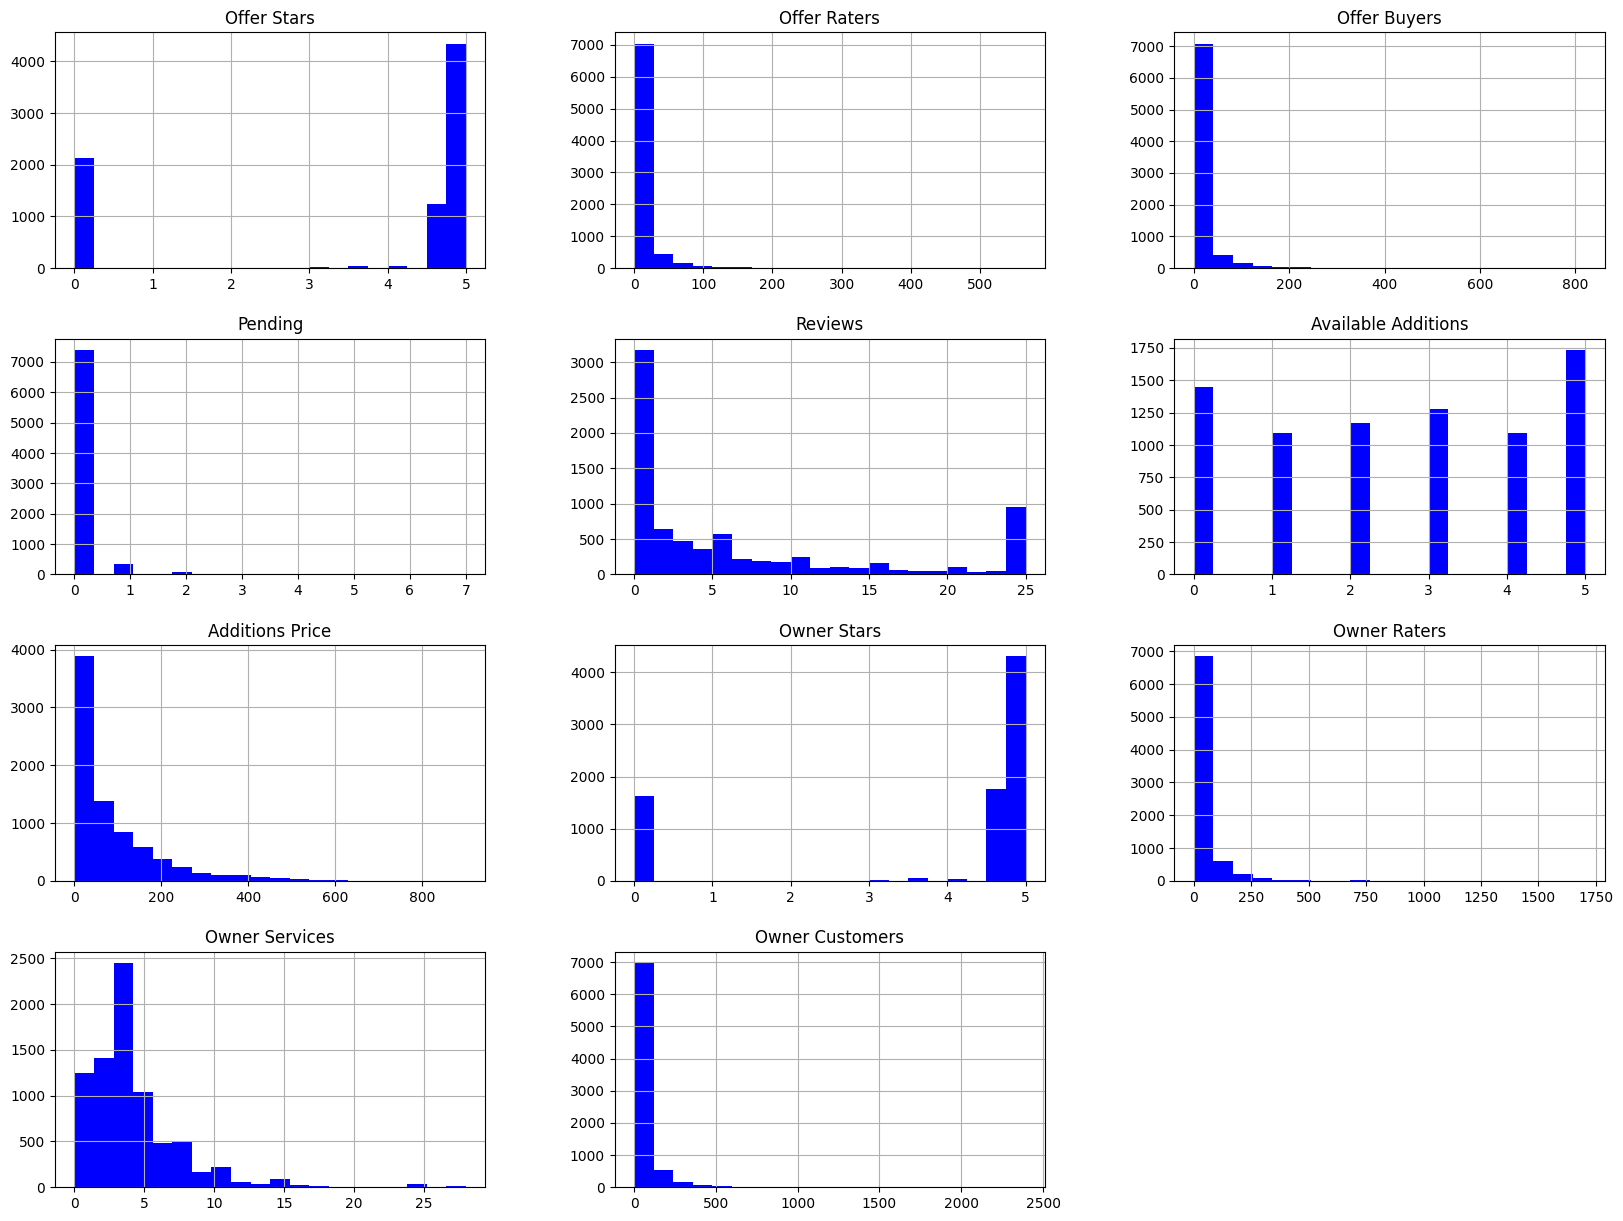

In [164]:
dataset.hist(figsize=(20, 15), bins=20, grid=True, color="blue")

plt.show()

In [148]:
duration_counts = dataset["Duration"].value_counts()

print(duration_counts)

Duration
يوم واحد        4007
يومين           1884
ثلاثة أيام      1011
أسبوع            276
أربعة أيام       216
خمسة أيام        184
شهر              115
أسبوعين           70
ستة أيام          35
ثلاثة أسابيع      20
Name: count, dtype: int64


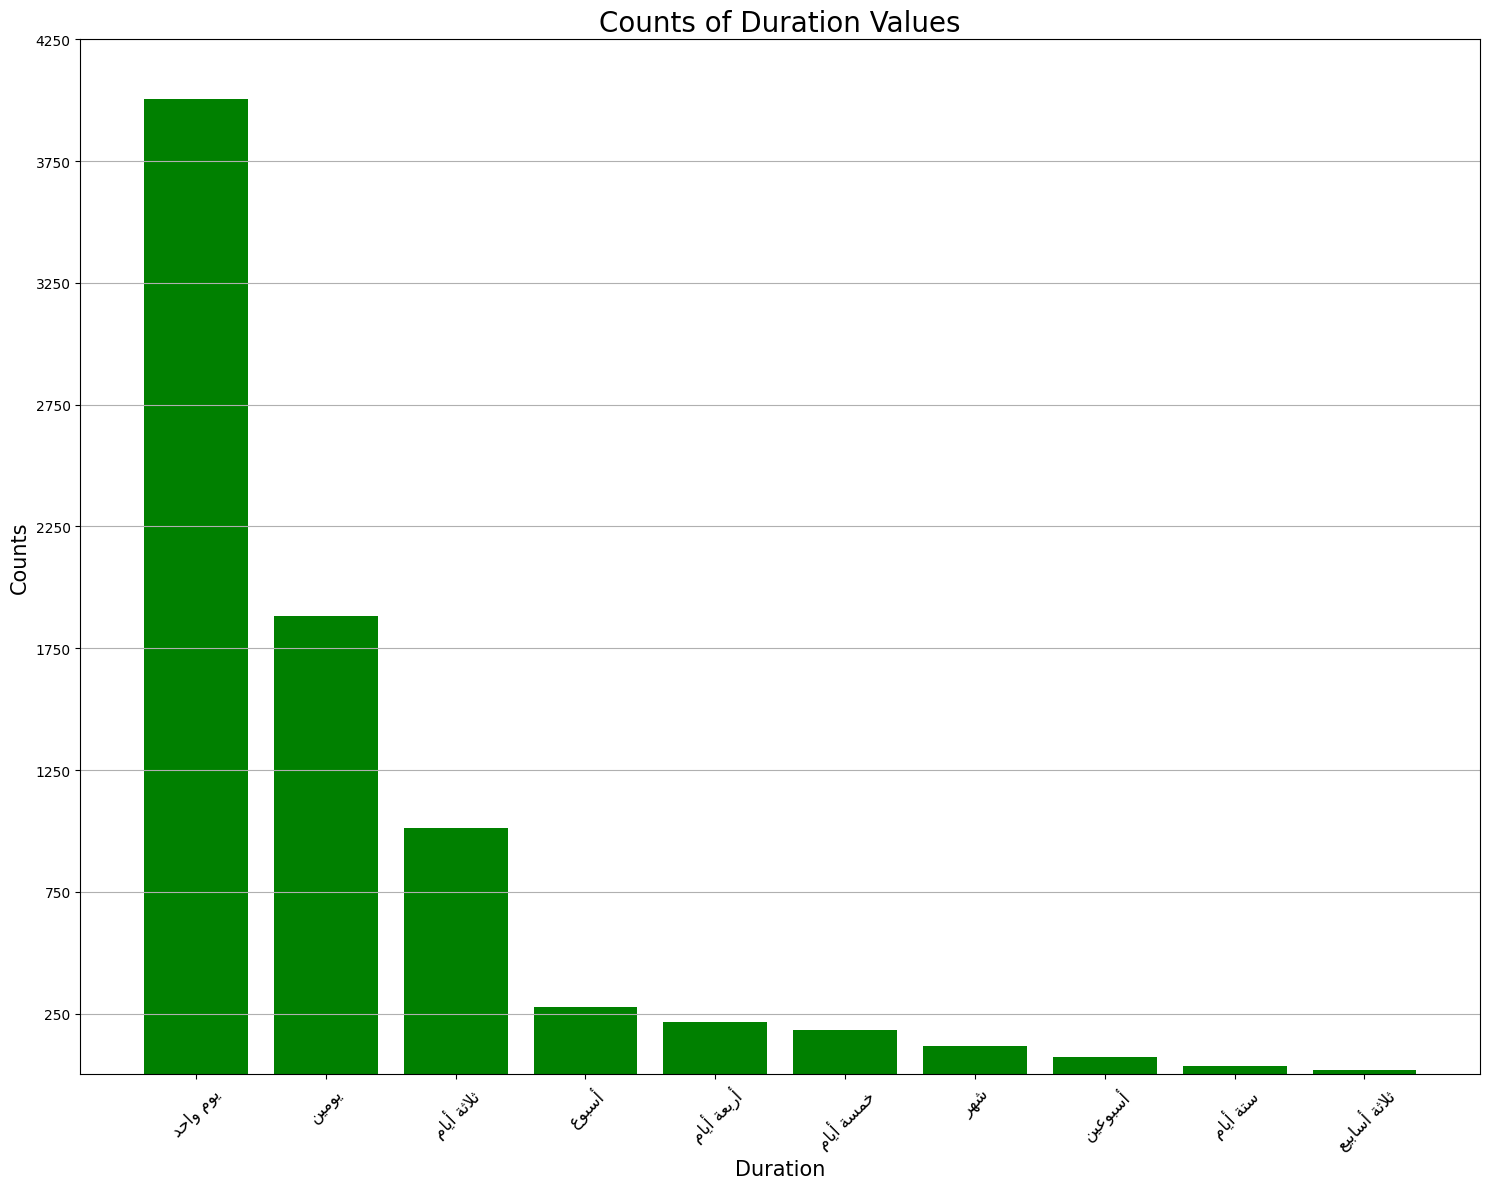

In [309]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in duration_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(15, 12))
plt.bar(display_labels, duration_counts.values, color="green")
plt.title("Counts of Duration Values", fontsize=20)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(range(250, int(max(duration_counts.values)) + 500, 500))
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [173]:
offer_response_time_counts = dataset["Offer Response Time"].value_counts() 

print(offer_response_time_counts)

Offer Response Time
لم يحسب    1806
ساعة        857
ساعتين      480
3 ساعات     347
يوم         315
           ... 
14 يوم        2
16 يوم        1
25 يوم        1
26 يوم        1
23 يوم        1
Name: count, Length: 104, dtype: int64


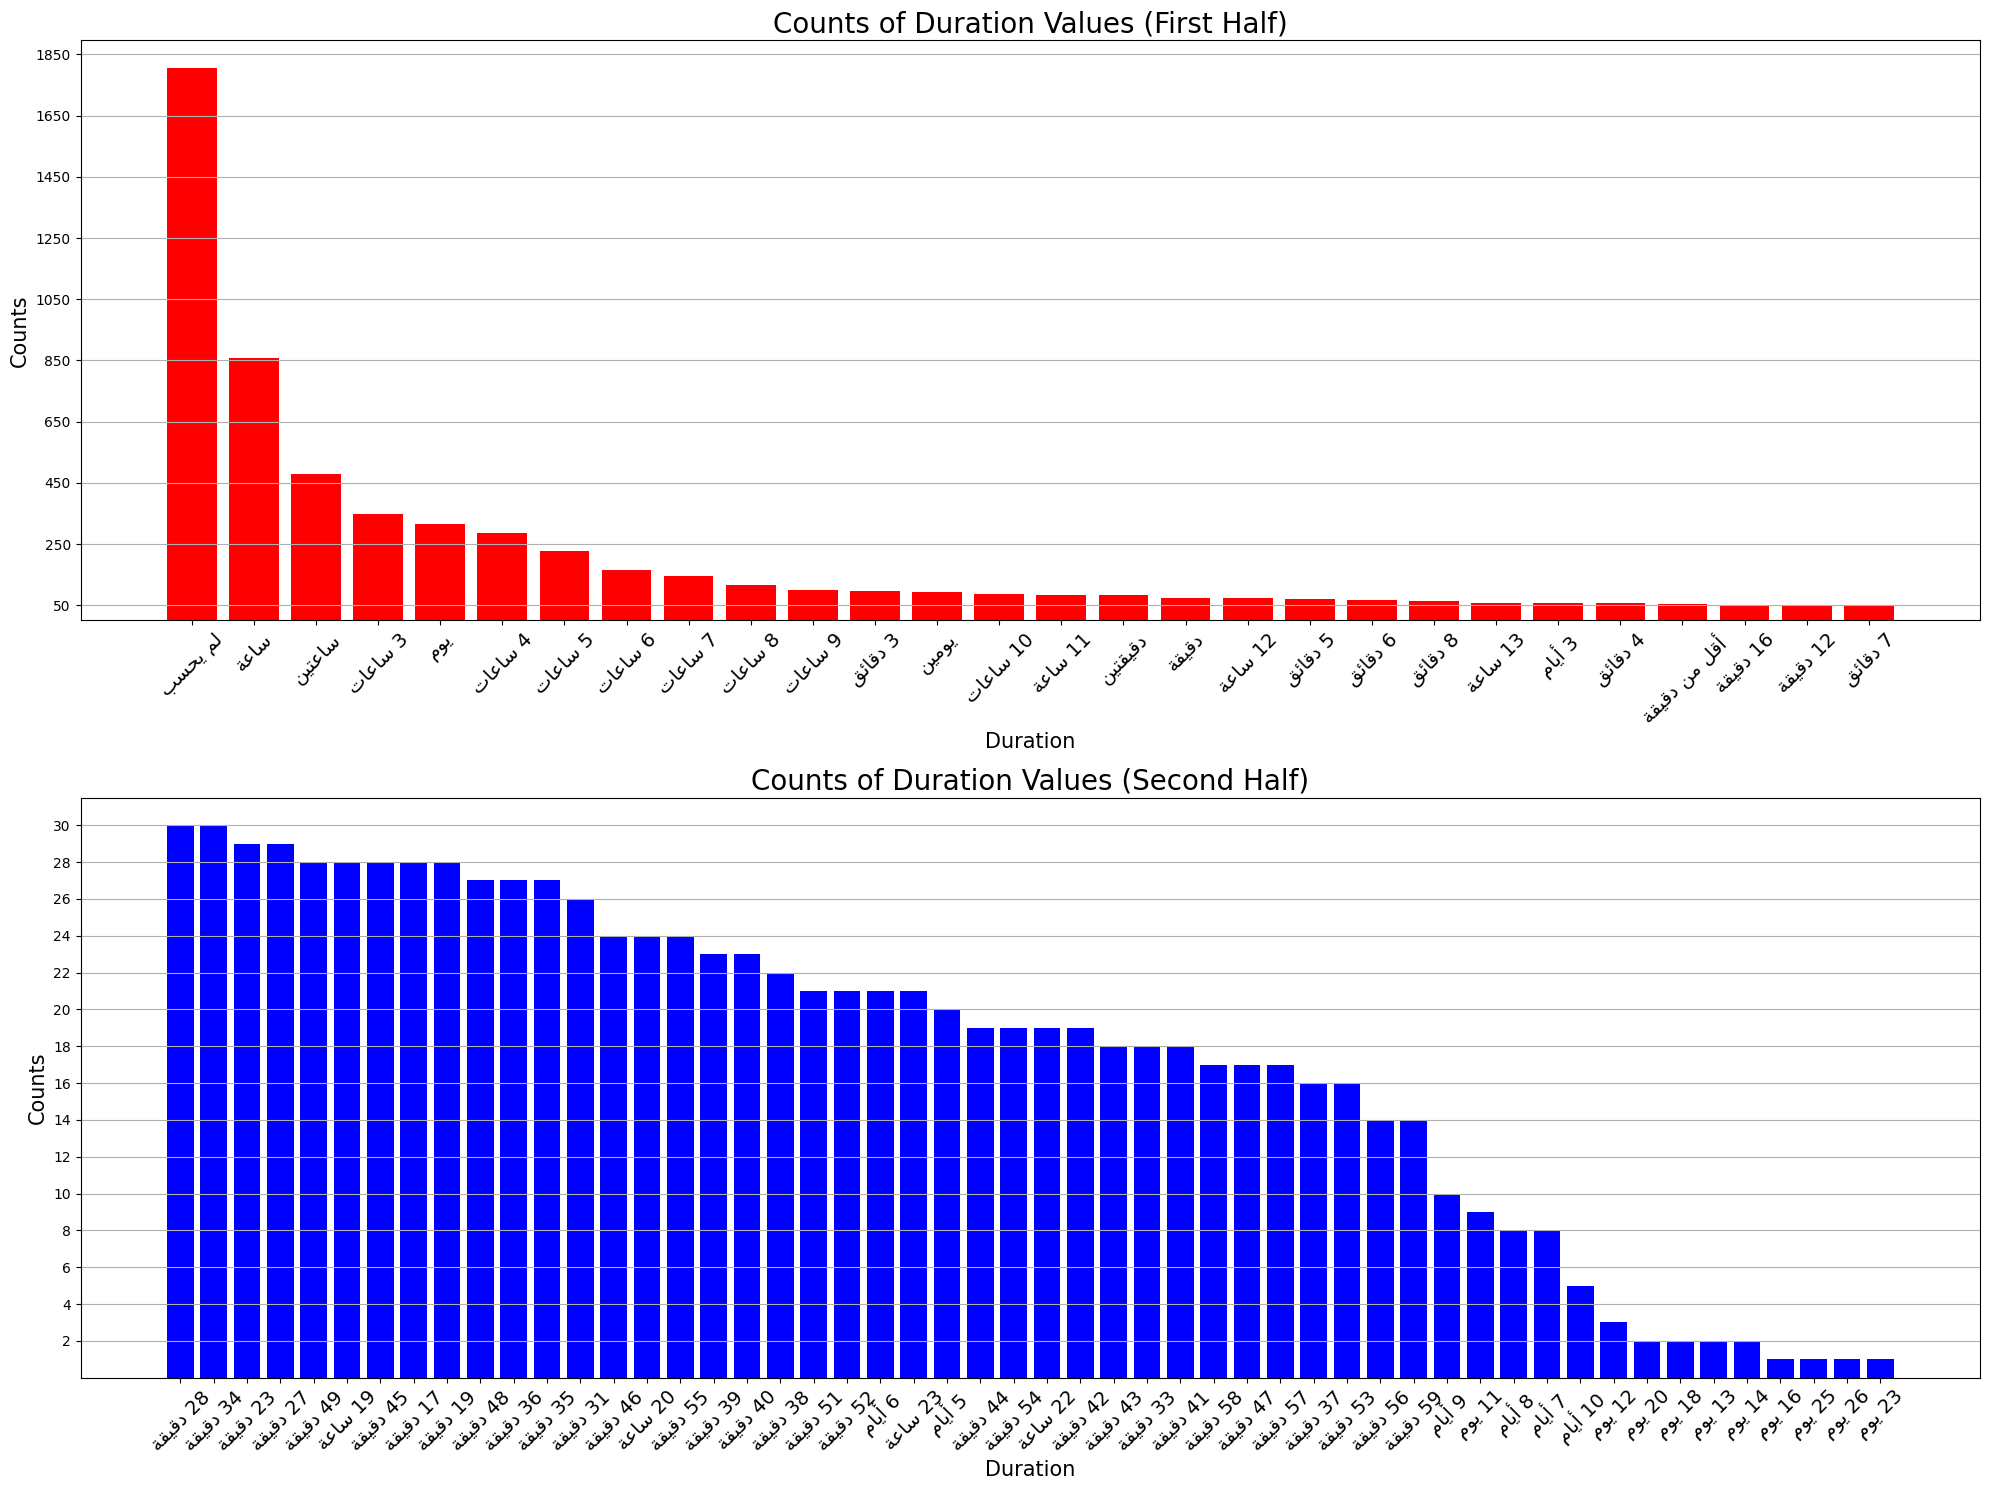

In [310]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in offer_response_time_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

mid_index = len(display_labels) // 2

first_half_labels = display_labels[:mid_index]
first_half_values = offer_response_time_counts.values[:mid_index]

filtered_first_half_labels = []
filtered_first_half_values = []

for label, value in zip(first_half_labels, first_half_values):
    if value > 50:
        filtered_first_half_labels.append(label)
        filtered_first_half_values.append(value)

second_half_labels = display_labels[mid_index:]
second_half_values = offer_response_time_counts.values[mid_index:]

plt.figure(figsize=(20, 15))

plt.subplot(2, 1, 1)
plt.bar(filtered_first_half_labels, filtered_first_half_values, color="red")
plt.title("Counts of Duration Values (First Half)", fontsize=20)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(range(50, int(max(filtered_first_half_values)) + 200, 200))
plt.grid(axis="y")
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.bar(second_half_labels, second_half_values, color="blue")
plt.title("Counts of Duration Values (Second Half)", fontsize=20)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(range(2, int(max(second_half_values)) + 2, 2))
plt.grid(axis="y")
plt.tight_layout()

plt.show()


In [331]:
owner_response_time_counts = dataset["Owner Response Time"].value_counts() 

print(owner_response_time_counts)

Owner Response Time
لم يحسب    1258
ساعة        906
ساعتين      703
3 ساعات     547
4 ساعات     427
           ... 
12 يوم        2
10 أيام       1
22 يوم        1
13 يوم        1
17 يوم        1
Name: count, Length: 102, dtype: int64


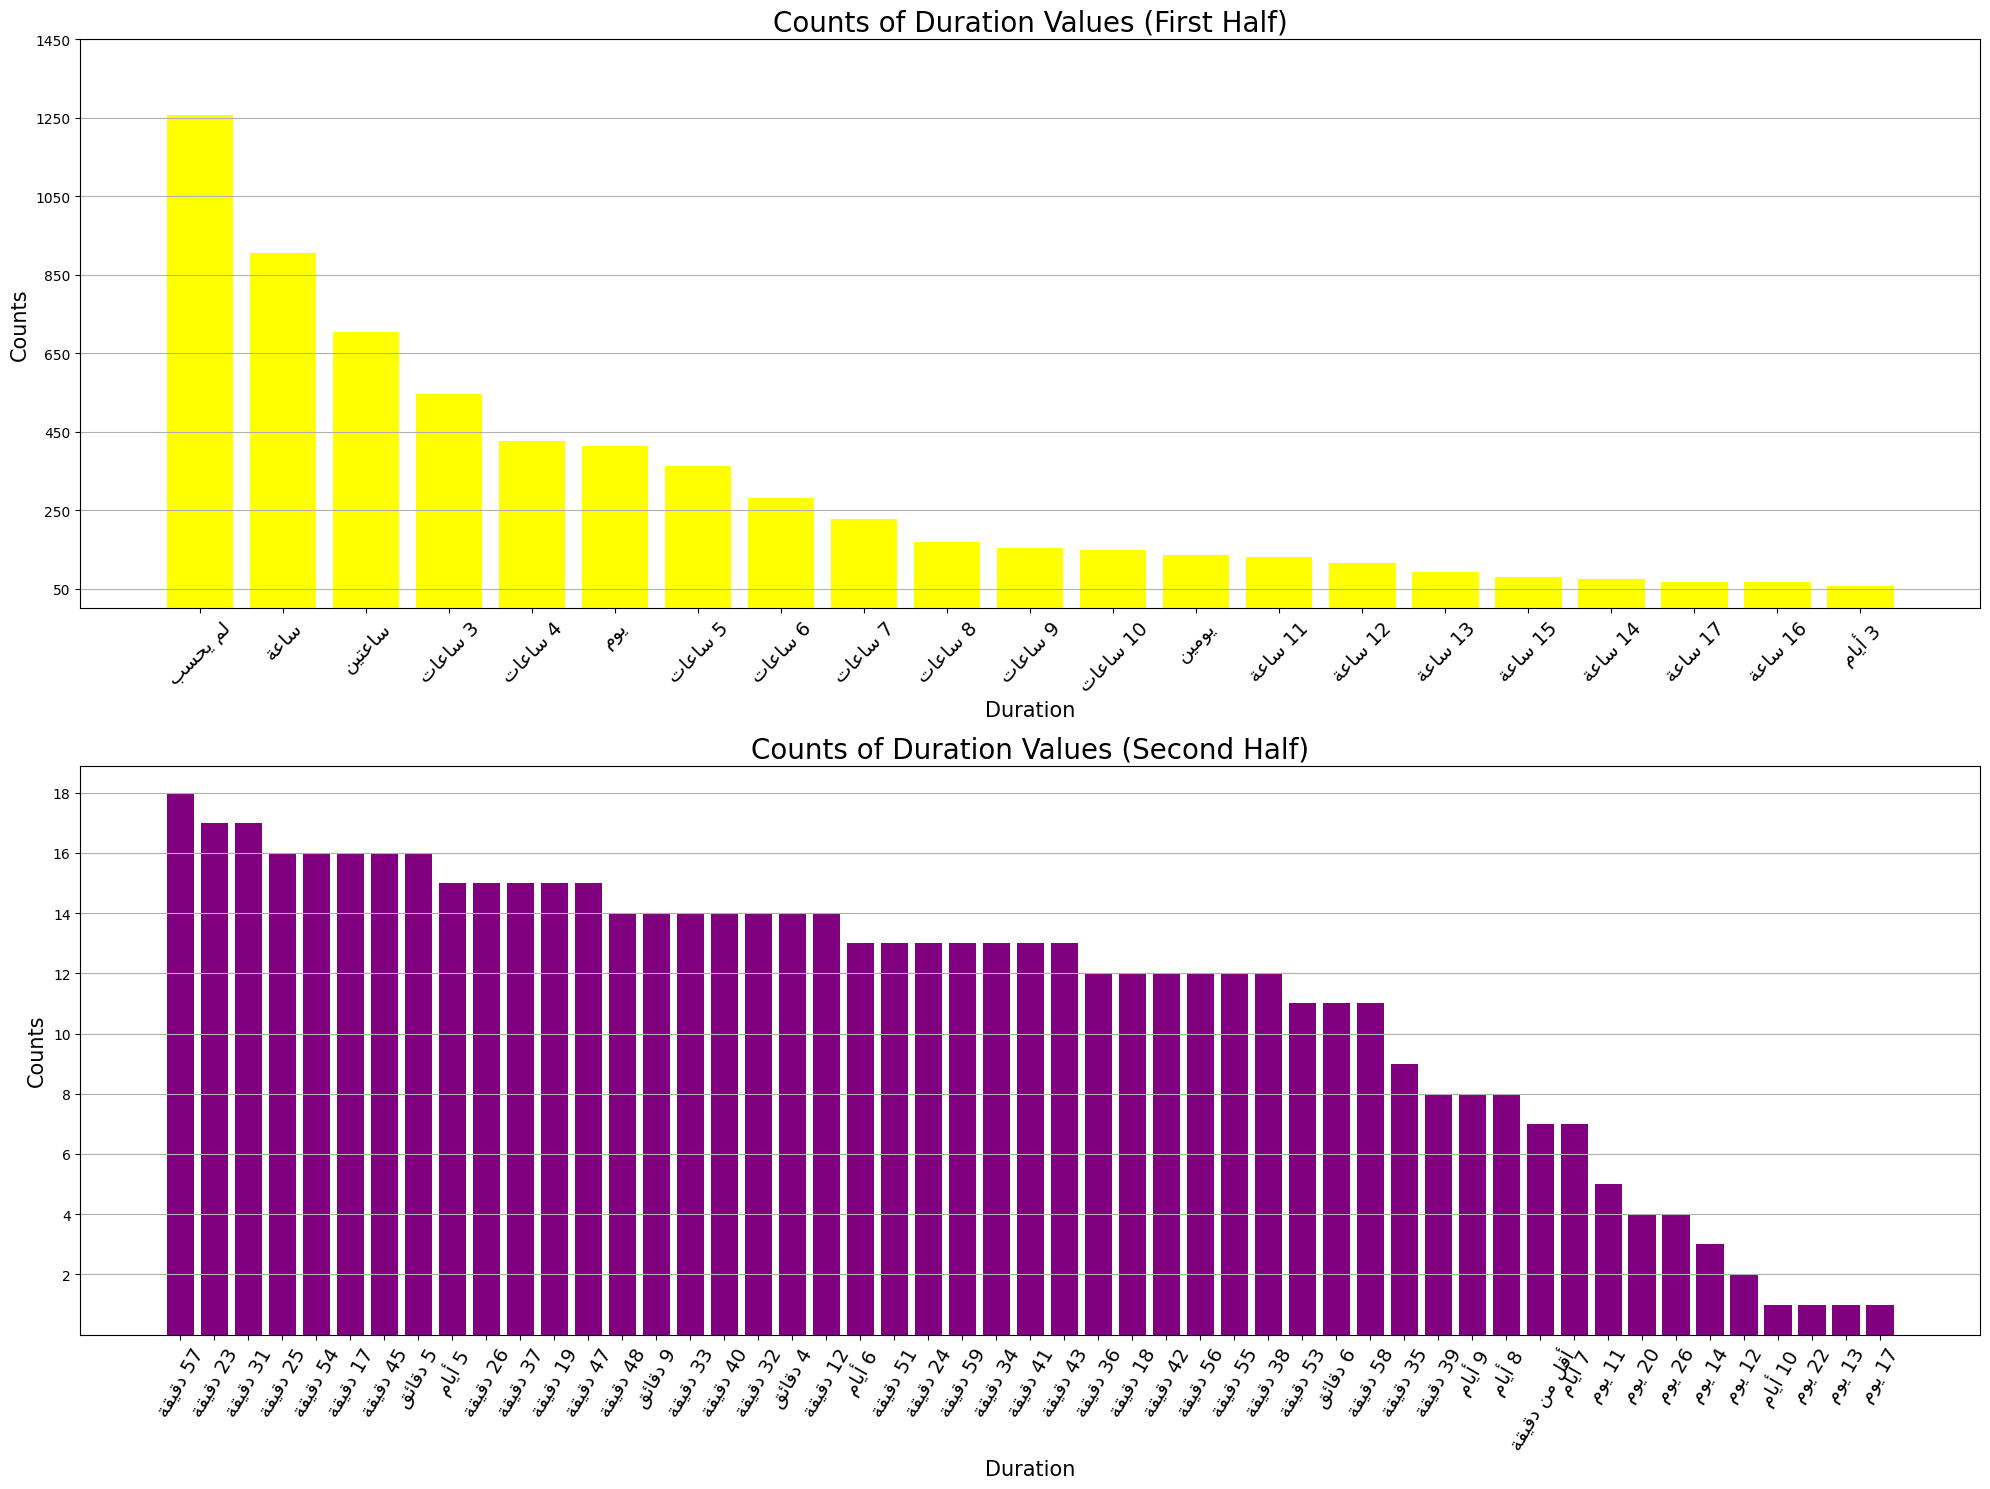

In [330]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in owner_response_time_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

mid_index = len(display_labels) // 2

first_half_labels = display_labels[:mid_index]
first_half_values = owner_response_time_counts.values[:mid_index]

filtered_first_half_labels = []
filtered_first_half_values = []

for label, value in zip(first_half_labels, first_half_values):
    if value > 50:
        filtered_first_half_labels.append(label)
        filtered_first_half_values.append(value)

second_half_labels = display_labels[mid_index:]
second_half_values = owner_response_time_counts.values[mid_index:]

plt.figure(figsize=(20, 15))

plt.subplot(2, 1, 1)
plt.bar(filtered_first_half_labels, filtered_first_half_values, color="yellow")
plt.title("Counts of Duration Values (First Half)", fontsize=20)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(range(50, int(max(filtered_first_half_values)) + 200, 200))
plt.grid(axis="y")
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.bar(second_half_labels, second_half_values, color="purple")
plt.title("Counts of Duration Values (Second Half)", fontsize=20)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(rotation=60, fontsize=14)
plt.yticks(range(2, int(max(second_half_values)) + 2, 2))
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [338]:
owner_completion_rate_counts = dataset["Owner Completion Rate"].value_counts() 

print(owner_completion_rate_counts)

Owner Completion Rate
100.0%         1484
لم يحسب بعد    1362
66.67%           73
85.71%           65
83.33%           65
               ... 
82.38%            1
84.3%             1
95.73%            1
66.0%             1
82.22%            1
Name: count, Length: 1240, dtype: int64


In [ ]:
# TODO: plot the above.

In [393]:
price_counts = dataset["Price"].value_counts() 

print(price_counts)

Price
$5.00     4341
$10.00    2371
$25.00     379
$15.00     250
$20.00     210
$50.00     170
$30.00      50
$35.00      20
$40.00      17
$45.00      10
Name: count, dtype: int64


In [ ]:
# TODO: plot the above.

#### Calculate the linear correlations (Person's R):

In [391]:
dataset_copy = dataset.copy()

dataset_copy["Price"] = dataset_copy["Price"].replace("[\$,]", "", regex=True).astype(float)

correlations = dataset_copy.select_dtypes(include=["int64", "float64", "bool"]).corr()

correlations

,Offer Stars,Offer Raters,Offer Buyers,Pending,Price,Reviews,Available Additions,Additions Price,Owner Verified,Owner Stars,Owner Raters,Owner Services,Owner Customers
Offer Stars,1.000000,0.244270,0.225626,0.105692,0.132717,0.464556,0.317984,0.249490,0.429240,0.832514,0.250201,0.202737,0.235031
Offer Raters,0.244270,1.000000,0.980466,0.175266,0.093609,0.684926,0.248509,0.204829,0.120803,0.205450,0.558053,0.064880,0.568685
Offer Buyers,0.225626,0.980466,1.000000,0.179318,0.082699,0.652421,0.221552,0.182733,0.113549,0.189785,0.556014,0.065530,0.589110
Pending,0.105692,0.175266,0.179318,1.000000,0.051882,0.188209,0.117811,0.114715,0.058940,0.093354,0.079442,0.009353,0.088987
Price,0.132717,0.093609,0.082699,0.051882,1.000000,0.139550,0.057321,0.308082,0.097847,0.157958,0.195740,0.243265,0.174025
Reviews,0.464556,0.684926,0.652421,0.188209,0.139550,1.000000,0.370275,0.302476,0.222808,0.390045,0.470112,0.129754,0.461772
Available Additions,0.317984,0.248509,0.221552,0.117811,0.057321,0.370275,1.000000,0.610348,0.186675,0.274399,0.160010,0.067862,0.143882
Additions Price,0.249490,0.204829,0.182733,0.114715,0.308082,0.302476,0.610348,1.000000,0.138419,0.223698,0.166539,0.109593,0.149928
Owner Verified,0.429240,0.120803,0.113549,0.058940,0.097847,0.222808,0.186675,0.138419,1.000000,0.504654,0.141866,0.177211,0.136581
Owner Stars,0.832514,0.205450,0.189785,0.093354,0.157958,0.390045,0.274399,0.223698,0.504654,1.000000,0.241654,0.274007,0.227651


In [392]:
correlations["Price"].sort_values(ascending=False)

Price                  1.000000
Additions Price        0.308082
Owner Services         0.243265
Owner Raters           0.195740
Owner Customers        0.174025
Owner Stars            0.157958
Reviews                0.139550
Offer Stars            0.132717
Owner Verified         0.097847
Offer Raters           0.093609
Offer Buyers           0.082699
Available Additions    0.057321
Pending                0.051882
Name: Price, dtype: float64